In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import lightning as L
from lightning_module import *
from net_utils import *
from data_utils import *
from plotting_utils import *

from sklearn.model_selection import train_test_split

import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

In [3]:
print(torch.cuda.is_available())
cuda_id = torch.cuda.current_device()
print(cuda_id)
print(torch.cuda.get_device_name(cuda_id))

True
0
NVIDIA A100-SXM4-80GB


Start by loading MC and PD files.

In [4]:
# Load mc
f_mc = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_train.root')
tree_mc = f_mc['OmniTree']
tree_mc.show(name_width=50)

name                                               | typename                 | interpretation                
---------------------------------------------------+--------------------------+-------------------------------
weight                                             | float                    | AsDtype('>f4')
pass190                                            | int32_t                  | AsDtype('>i4')
truth_pass190                                      | int32_t                  | AsDtype('>i4')
weight_mc                                          | float                    | AsDtype('>f4')
prw                                                | float                    | AsDtype('>f4')
pass190_syst_ID_Up                                 | int32_t                  | AsDtype('>i4')
pass190_syst_ID_Down                               | int32_t                  | AsDtype('>i4')
pass190_syst_MS_Up                                 | int32_t                  | AsDtype('>i4')
pass190_syst_MS_Do

In [5]:
f_pd = uproot.open('/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files/WithTracks_ZjetOmnifold_Aug5_PseudoDataSRew_Dec15.root')
tree_pd = f_pd['OmniTree']
tree_pd.show(name_width=50)

name                                               | typename                 | interpretation                
---------------------------------------------------+--------------------------+-------------------------------
weight                                             | float                    | AsDtype('>f4')
pass190                                            | int32_t                  | AsDtype('>i4')
truth_pass190                                      | int32_t                  | AsDtype('>i4')
weight_mc                                          | float                    | AsDtype('>f4')
prw                                                | float                    | AsDtype('>f4')
pT_ll                                              | float                    | AsDtype('>f4')
pT_l1                                              | float                    | AsDtype('>f4')
pT_l2                                              | float                    | AsDtype('>f4')
eta_l1            

Next we need to build torch tensors from the data. One open question is how to handle the muon kinematics, since they are distinct from the tracks. For now I will include the muon information in the same way as the tracks, but this should be changed in the future. Probably the best way is to include a one-hot encoded input, which tells the network where the 3-vector is a muon, track from 1st jet, track from 2nd jet, etc.

In [6]:
# Pass 190 flags
pass190_mc = ak.to_numpy(tree_mc['pass190'].array())
print("We have a fracion {} of good events in mc".format(np.sum(pass190_mc) / len(pass190_mc)))
pass190_pd = ak.to_numpy(tree_pd['pass190'].array())
print("We have a fracion {} of good events in pseudodata".format(np.sum(pass190_pd) / len(pass190_pd)))

We have a fracion 0.8144455536320278 of good events in mc
We have a fracion 1.0 of good events in pseudodata


In [7]:
# Load MC kinematics
mc_kinematics, mc_mask = get_kinematics(tree_mc, filter=pass190_mc)
print(mc_kinematics.shape)
print(mc_mask.shape)


(1160150, 3, 294)
(1160150, 1, 294)


In [8]:
# Load pseudodata kinematics
pd_kinematics, pd_mask = get_kinematics(tree_pd, filter=pass190_pd, max_tracks=mc_kinematics.shape[2]-2)
print(pd_kinematics.shape)
print(pd_mask.shape)

Warning! Track kinematics shape does not match muon kinematics shape!
(235917, 3, 294)
(235917, 1, 294)


Next we need to load the weights. For MC this is easy. For pseudodata we need to take the missing track events into account.

In [9]:
# MC weights
mc_weights = ak.to_numpy(tree_mc['weight'].array())
mc_weights = np.expand_dims(mc_weights[pass190_mc == 1], axis=1)
print(mc_weights.shape)

(1160150, 1)


In [10]:
# Pseudodata weights
pd_weights = ak.to_numpy(tree_pd['weight'].array())
pd_weights = np.expand_dims(pd_weights[pass190_pd == 1], axis=1)

# Drop 11k weights at the end since we don't have tracks for those events
pd_weights = pd_weights[:pd_kinematics.shape[0]]

print(pd_weights.shape)

(235917, 1)


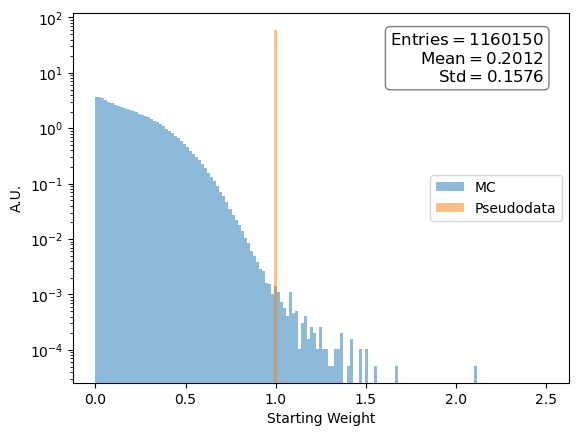

In [11]:
bins = np.linspace(0, 2.5, 150)
plt.hist(mc_weights, bins=bins, alpha=0.5, label='MC', density=True)
plt.hist(pd_weights, bins=bins, alpha=0.5, label='Pseudodata', density=True)
add_stats_box(plt.gca(), mc_weights)
plt.legend(loc='center right')
plt.yscale('log')
plt.xlabel('Starting Weight')
plt.ylabel('A.U.')
plt.show()

In [12]:
class_ratio = np.sum(mc_weights) / np.sum(pd_weights)
print("Class ratio: {}".format(class_ratio))

Class ratio: 0.9892692565917969


Make the labels. We will call pseudodata signal, and MC background.

In [13]:
# Build labels
mc_labels = np.zeros((mc_kinematics.shape[0], 1), dtype=np.float32)
pd_labels = np.ones((pd_kinematics.shape[0], 1), dtype=np.float32)

Concatenate MC and PD together. Since with the weights the class ratio is nearly one, just use all of the events

In [14]:
# Concatenate MC and pseudodata together
kinematics = np.concatenate([mc_kinematics, pd_kinematics], axis=0)
mask = np.concatenate([mc_mask, pd_mask], axis=0)
weights = np.concatenate([mc_weights, pd_weights], axis=0)
labels = np.concatenate([mc_labels, pd_labels], axis=0)

Make the one-hot encoding dimensions which identify whether the object is a muon or a track

In [15]:
# Make one-hot encoding identifying whether the object is a muon or a track
is_muon = np.concatenate([np.ones((kinematics.shape[0], 2)), np.zeros((kinematics.shape[0], kinematics.shape[2]-2))], axis=1)
is_track = np.concatenate([np.zeros((kinematics.shape[0], 2)), np.ones((kinematics.shape[0], kinematics.shape[2]-2))], axis=1)
one_hot = np.stack([is_muon, is_track], axis=1)
print(one_hot.shape)

(1396067, 2, 294)


Concatenate one-hot encoding dimensions onto the kinematics

In [16]:
kinematics = np.concatenate([kinematics, one_hot], axis=1)

Finally done cleaning data. For the purposes of this eval just going to use all of the data. We can check for overtraining later but I don't think there was any based on loss values

In [17]:
# Convert to torch tensors
device = 'cuda:0'
kinematics = torch.tensor(kinematics, dtype=torch.float32).to(device).contiguous()
labels = torch.tensor(labels, dtype=torch.float32).to(device)
mask = torch.tensor(mask, dtype=torch.float32).to(device)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

In [18]:
# Build a pytorch dataset
test_dataset = torch.utils.data.TensorDataset(kinematics, labels, mask, weights)

In [19]:
# Build pytorch data loaders
batch_size = 256
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

Data is ready. Next we need to load a model from a pytorch lightning checkpoint

In [20]:
model = LOfTransformer.load_from_checkpoint(
    'checkpoints/test-of-project/8oyq29pw/checkpoints/epoch=36-val_loss=0.2053.ckpt'
)

Batch normalization disabled in embedding!


Now evaluate the model over the test dataloader

In [22]:
trainer = L.Trainer(accelerator='gpu', devices=1)
predictions = trainer.predict(model, test_loader)

/global/homes/k/kgreif/.conda/envs/zjets/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /global/homes/k/kgreif/.conda/envs/zjets/lib/python3 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/global/homes/k/kgreif/.conda/envs/zjets/lib/python3.11/site-packages/lightning/

Predicting: |          | 0/? [00:00<?, ?it/s]

In [23]:
predictions = np.concatenate([pred.cpu().numpy().flatten() for pred in predictions])
print(predictions.shape)

(1396067,)


In [24]:
# Save predictions as a numpy array
np.save('first_predictions.npy', predictions)

In [25]:
# Calculate weights from predictions
probs = 1 / (1 + np.exp(-predictions))
derived_weights = probs / (1 - probs)

In [30]:
# Move kinematics to cpu
weights = weights.cpu().numpy()

In [31]:
# Extract muon kinematics
alldata = {}
alldata['m1_pt'] = np.exp(kinematics[:, 0, 0])
alldata['m2_pt'] = np.exp(kinematics[:, 0, 1])
alldata['m1_eta'] = kinematics[:, 1, 0]
alldata['m2_eta'] = kinematics[:, 1, 1]
alldata['m1_phi'] = kinematics[:, 2, 0]
alldata['m2_phi'] = kinematics[:, 2, 1]
alldata['end_weights'] = weights * derived_weights
alldata['start_weights'] = weights
v1 = np.stack([alldata['m1_pt'] * np.cos(alldata['m1_phi']), alldata['m1_pt'] * np.sin(alldata['m1_phi']), alldata['m1_pt'] * np.sinh(alldata['m1_eta'])], axis=1)
v2 = np.stack([alldata['m2_pt'] * np.cos(alldata['m2_phi']), alldata['m2_pt'] * np.sin(alldata['m2_phi']), alldata['m2_pt'] * np.sinh(alldata['m2_eta'])], axis=1)
vall = v1 + v2
print(v1.shape)
print(vall.shape)
print(vall[:10,:])
alldata['mm_pt'] = np.sqrt(vall[:,0]**2 + vall[:,1]**2)

# Extract labels
labels = test_dataset[:][1].detach().cpu().numpy().flatten()

# Separate MC and pseudodata
mc_data = {key: val[labels == 0] for key, val in alldata.items()}
pd_data = {key: val[labels == 1] for key, val in alldata.items()}

: 

: 

In [ ]:
print(np.mean(mc_data['start_weights']))
print(np.mean(mc_data['end_weights']))
print(np.mean(pd_data['start_weights']))
print(np.mean(pd_data['end_weights']))

In [ ]:
from plotting_utils import *
fig = plot_reweighting(mc_data['m1_pt'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m1_pt'], bins=np.linspace(0, 1e3, 200), xlabel=r'$p_{T, \mu_1}$ [GeV]', rlim=[0.95, 1.05])
fig.show()
fig = plot_reweighting(mc_data['m2_pt'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m2_pt'], bins=np.linspace(0, 800, 200), xlabel=r'$p_{T, \mu_2}$ [GeV]')
fig.show()
fig = plot_reweighting(mc_data['m1_eta'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m1_eta'], bins=np.linspace(-2.5, 2.5, 200), xlabel=r'$\eta_{\mu_1}$')
fig.show()
fig = plot_reweighting(mc_data['m2_eta'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m2_eta'], bins=np.linspace(-2.5, 2.5, 200), xlabel=r'$\eta_{\mu_2}$')
fig.show()
fig = plot_reweighting(mc_data['m1_phi'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m1_phi'], bins=np.linspace(-np.pi, np.pi, 200), xlabel=r'$\phi_{\mu_1}$', linear_scale=True, ylim=[0, 0.2])
fig.show()
fig = plot_reweighting(mc_data['m2_phi'], mc_data['start_weights'], mc_data['end_weights'], pd_data['m2_phi'], bins=np.linspace(-np.pi, np.pi, 200), xlabel=r'$\phi_{\mu_2}$', linear_scale=True, ylim=[0, 0.2])
fig.show()
fig = plot_reweighting(mc_data['mm_pt'], mc_data['start_weights'], mc_data['end_weights'], pd_data['mm_pt'], bins=np.linspace(0, 1e3, 200), xlabel=r'$p_{T, \mu\mu}$ [GeV]')
fig.show()

Lovely. We're getting all 6 dimensions plus one derived dimension with acceptable precision for now. This is great. Let's try training and evaluating something like this in production mode, and logging these plots during training. That way I can look for any overfitting effects.